<a href="https://colab.research.google.com/github/Hemn-Khdr/intro-ml-course-winter2025/blob/ML-project-Final/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing Packages


In [2]:
# run the line below if you don't have these packages installed
# you can comment out this line after installing
!pip install -q contractions nltk gensim
#the '-q' can be removed, it just supresses the outputs from these package installations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 5.2 MB/s eta 0:00:00


In [1]:
!pip install numpy==1.23.5 --upgrade --force-reinstall


  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.23.5 which is incompatible.
albucore 0.0.23 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
blosc2 3.2.0 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you hav

In [1]:
# Import key packages for data processing and NLP

import pandas as pd  # Library for handling structured data (e.g., DataFrames) efficiently

# Import the necessary libraries for text preprocessing
import contractions  # Allows us to handle text contractions (e.g., "can't" -> "cannot")
import re  # Used for finding and replacing text patterns (e.g., removing special characters)
from datetime import datetime  # Provides functions for handling date and time operations

# Import NLTK (Natural Language Toolkit) for text tokenization
import nltk
from nltk.tokenize import word_tokenize  # Tokenizes text into individual words
nltk.download('punkt')  # Downloads the tokenizer model which we'll be using
nltk.download('punkt_tab')

# Import the 'stopwords' corpus from NLTK (Natural Language Toolkit)
from nltk.corpus import stopwords
nltk.download('stopwords')  # Downloads the predefined list of common stopwords from NLTK.

# WordCloud for visualizing the frequency of words in text data
from wordcloud import WordCloud
import matplotlib.pyplot as plt  # Library for plotting and visualization

# Libraries for lemmatization (reducing words to their base form)
from nltk.stem import WordNetLemmatizer  # Performs lemmatization
from nltk.corpus import wordnet  # Provides a lexical database for lemmatization
nltk.download('averaged_perceptron_tagger')  # Downloads the model for part-of-speech tagging
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')  # Downloads the WordNet lexical database

# Libraries for word embeddings (vector representations of words)
import gensim.downloader as api  # Getting our pre-trained word embedding models
import numpy as np  # Numerical computing library for handling arrays and matrices

# package to handle warnings
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
from google.colab import files
import io
import pandas as pd

# Upload the Excel file
uploaded = files.upload()

# Load the Excel file (adjusted for your file name and structure)
df = pd.read_excel(io.BytesIO(uploaded['NLP.xlsx']))

# Since your dataset only has one column: 'abstract', no need to filter more
# Display the first few rows to confirm everything loaded correctly
df.head()


Saving NLP.xlsx to NLP.xlsx


,abstract
0,Post-stroke anxiety (PSA) has caused wide publ...
1,Introduction: Post-stroke depression (PSD) is ...
2,"Currently, the identification of stroke patien..."
3,Cardiovascular disease (CVD) is a major compli...
4,Depression is a common complication after a st...


When processing text data, it is essential to ensure that the text is correctly encoded and free of any characters that may have been incorrectly interpreted or displayed due to encoding issues. In the example provided:

`I¡¯d rather contract COVID-19 than get the vac...`

The sequence `¡¯` is likely meant to represent an apostrophe in the contraction "I'd" (I would). However, due to an encoding mismatch, the apostrophe is displayed as `¡¯`. This can lead to problems such as:

- **Incorrect Text Analysis**: NLP algorithms may treat `I¡¯d` as a single, unique word rather than the intended contraction "I'd", which could skew text analysis results.
- **Search and Match Issues**: Searching the text for common words or phrases may fail because the unusual characters disrupt the expected patterns.
- **User Experience**: For any application that presents this text to users, such misencoding can be confusing and give an impression of poor data quality.

By cleaning the text and replacing `¡¯` with the correct apostrophe, you can avoid these issues and ensure that the text is processed accurately for analysis, searching, or display purposes.

In [3]:
# Define a cleaning function that will replace incorrectly encoded characters
def clean_encoding(text):
    text = text.replace('¡¯', "'")  # Replace the sequence that represents a single quote
    # Add more replacements here if needed
    return text

# Apply the cleaning function to the 'abstract' column of the DataFrame
df['abstract'] = df['abstract'].apply(clean_encoding)

# Show the first few cleaned rows
df.head()


,abstract
0,Post-stroke anxiety (PSA) has caused wide publ...
1,Introduction: Post-stroke depression (PSD) is ...
2,"Currently, the identification of stroke patien..."
3,Cardiovascular disease (CVD) is a major compli...
4,Depression is a common complication after a st...


Handling Text Contractions in Preprocessing

Handling contractions is an important step in text preprocessing, especially for English language data. Contractions are words or combinations of words that are shortened by dropping letters and replacing them with an apostrophe, like "I'm" for "I am" or "you're" for "you are".

In many NLP tasks, especially those involving sentiment analysis, expanding these contractions is beneficial. This expansion makes the text more standardized and easier for algorithms to understand. For example, expanding "I'm" to "I am" makes it clear that the sentence is in the first person and present tense, which might be important for the analysis.

Here is how you can handle contractions:

Use a Pre-built Library: Python libraries like contractions can automatically handle common English contractions. You can install it via pip (pip install contractions) and then use it to replace contractions in your text. We already installed and imported this package at the start of the tutorial.

Manually Define a Mapping: If you prefer not to use an external library, or if you have specific contraction cases you want to handle, you can manually define a dictionary of contractions and their expansions and use it to replace contractions in your text.

Here is a brief example using the contractions library:

In [4]:
import re
import contractions

# Define a safe function to expand contractions in the abstract column
def safe_expand_contractions(text):
    # Temporarily protect possessives (e.g., "vaccine's") so they aren't wrongly expanded
    text = re.sub(r"(\w+)'s\b", r"\1_POSSESSIVE", text)

    # Expand contractions
    text = contractions.fix(text)

    # Restore possessives
    text = text.replace("_POSSESSIVE", "'s")

    return text

# Apply the function to your DataFrame's 'abstract' column
df['abstract'] = df['abstract'].apply(safe_expand_contractions)

# Preview the cleaned data
df.head()


,abstract
0,Post-stroke anxiety (PSA) has caused wide publ...
1,Introduction: Post-stroke depression (PSD) is ...
2,"Currently, the identification of stroke patien..."
3,Cardiovascular disease (CVD) is a major compli...
4,Depression is a common complication after a st...


This approach will ensure that your text data is more uniform and easier to analyze, especially when dealing with informal language often found in social media posts like tweets.

In [5]:
# Expand contractions in the 'abstract' column using the safe method
df['abstract_expanded'] = df['abstract'].apply(lambda x: safe_expand_contractions(x))

# Preview the result
df.head()


,abstract,abstract_expanded
0,Post-stroke anxiety (PSA) has caused wide publ...,Post-stroke anxiety (PSA) has caused wide publ...
1,Introduction: Post-stroke depression (PSD) is ...,Introduction: Post-stroke depression (PSD) is ...
2,"Currently, the identification of stroke patien...","Currently, the identification of stroke patien..."
3,Cardiovascular disease (CVD) is a major compli...,Cardiovascular disease (CVD) is a major compli...
4,Depression is a common complication after a st...,Depression is a common complication after a st...


Note: If we had not corrected the misencoded characters in the previous step, we would not be able to effectively handle contractions in the text. The presence of incorrect characters like ¡¯ in place of an apostrophe would prevent text processing algorithms from recognizing and properly managing contractions. For example, "I¡¯d" would not be identified as the contraction "I'd", and therefore would not be expanded to "I would". This highlights the order of the tasks that need to be performed when it comes to text data preprocessing.

Text Data Standardization

Converting the date column to datetime format:

The purpose of this step is to ensure that the date and time information in the dataset is recognized by the computer in a standardized format that is universally understood. By converting strings that represent date and time into a datetime object, we enable the computer to perform operations that are specific to dates and times, such as sorting based on time or filtering entries within a certain date range.
Lowercasing all text in the 'tweet' column:

The goal here is to achieve consistency in the dataset by converting all the text to lowercase. This is important because the sentiment analysis algorithm might otherwise treat the same words with different cases as distinct, leading to inaccuracies in the analysis.
The line df['tweet'] = df['tweet'].str.lower() is used to convert all the text in the 'tweet' column of the DataFrame 'df' to lowercase.
.str is used to access string methods and operations on the elements within the selected column.
.lower() is a string method that converts all the characters in a string to lowercase.
Removing URLs from the tweets:

URLs are typically irrelevant to the sentiment expressed in the tweet and can be distracting to the analysis. The regular expression r'http\S+' is used to find and remove these. Here, http is the literal string that URLs usually start with, \S+ matches a sequence of non-whitespace characters (which in the context of URLs, can be anything until a space is encountered). This expression matches the whole URL, and we replace it with an empty string, effectively removing it from the tweet.
Removing Twitter handles:

Twitter handles (e.g., @username) are identifiers and do not contribute to sentiment. The regular expression r'@\w+' matches these handles. The @ is the literal character we are looking for, and \w+ matches one or more word characters (letters, digits, or underscores) that come after it. This matches the entire handle, which we then remove.
Removing special characters and numbers:

Special characters and numbers generally do not carry sentiment and can be removed to simplify the analysis. The regular expression r'[^A-Za-z\s]' is used for this purpose. The [^ ] denotes a set of characters we do not want (the caret ^ means "not" in this context). Inside the brackets, A-Za-z specifies any uppercase or lowercase letter, and \s allows for any whitespace characters (like spaces or tabs) to be retained. So, this regular expression matches any character that is not a letter or whitespace and removes it.
Correcting the spelling of "Neutral" in the 'Emotion' column:

Ensuring that categories are labeled correctly is important for accurate analysis. There is no regular expression used in this step. Instead, we simply replace the misspelled or varied spellings of "Neutral" with the correct one to maintain consistency across the dataset.
These steps aim to create a dataset that focuses only on the text that is likely to carry sentiment, making it easier for the sentiment analysis algorithm to operate effectively and accurately. Regular expressions are like search patterns that we define to find specific sequences of characters within text, and they are a powerful tool for text processing and data cleaning.

In [6]:
import re
import pandas as pd

# === Define Cleaning Functions ===

# Function to remove URLs
def remove_url(text):
    return re.sub(r'http\S+|www.\S+', '', text)

# Function to remove Twitter handles (if any exist)
def remove_handle(text):
    return re.sub(r'@\w+', '', text)

# Function to remove special characters and numbers
def remove_special_characters(text):
    return re.sub(r'[^A-Za-z\s]', '', text)

# === Data Cleaning Steps ===

# 1. Convert 'date' column to datetime if it exists
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Lowercase the text in 'abstract_expanded'
df['abstract_expanded'] = df['abstract_expanded'].str.lower()

# 3. Remove URLs, handles, special characters, and clean up whitespace
df['abstract_expanded'] = df['abstract_expanded'].apply(remove_url)
df['abstract_expanded'] = df['abstract_expanded'].apply(remove_handle)
df['abstract_expanded'] = df['abstract_expanded'].apply(remove_special_characters)
df['abstract_expanded'] = df['abstract_expanded'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())


# Preview cleaned data
df.head()


,abstract,abstract_expanded
0,Post-stroke anxiety (PSA) has caused wide publ...,poststroke anxiety psa has caused wide public ...
1,Introduction: Post-stroke depression (PSD) is ...,introduction poststroke depression psd is a se...
2,"Currently, the identification of stroke patien...",currently the identification of stroke patient...
3,Cardiovascular disease (CVD) is a major compli...,cardiovascular disease cvd is a major complica...
4,Depression is a common complication after a st...,depression is a common complication after a st...


Tokenization

Tokenization is a foundational step in most natural language processing tasks. It is the process of converting a sequence of characters into a sequence of tokens (words, phrases, symbols, or other meaningful elements called lexemes).

Here is a snapshot of how tokenization works

In [7]:
import nltk
from nltk.tokenize import word_tokenize

# Download NLTK tokenizer model
nltk.download('punkt')

# Define a function to tokenize text
def tokenize_text(text):
    return word_tokenize(text)

# Apply the tokenization function to the cleaned abstract column
df['tokens'] = df['abstract_expanded'].apply(tokenize_text)

# Preview the DataFrame with the new tokens column
df[['abstract_expanded', 'tokens']].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,abstract_expanded,tokens
0,poststroke anxiety psa has caused wide public ...,"[poststroke, anxiety, psa, has, caused, wide, ..."
1,introduction poststroke depression psd is a se...,"[introduction, poststroke, depression, psd, is..."
2,currently the identification of stroke patient...,"[currently, the, identification, of, stroke, p..."
3,cardiovascular disease cvd is a major complica...,"[cardiovascular, disease, cvd, is, a, major, c..."
4,depression is a common complication after a st...,"[depression, is, a, common, complication, afte..."


Stop Words

Stop words are words which are filtered out before or after processing of text. When building the vocabulary of known words for a language model, it is a common practice to exclude words that carry very little informative power, typically because they occur very frequently in the language. These include words like "the", "is", "in", and "and" in English. They are called stop words because they are often removed, or "stopped", from the text before performing natural language processing tasks.

Types of Stop Words
General Stop Words: These are the words that are commonly used in the language and do not contribute much to the meaning of a sentence. They can be safely ignored without sacrificing the meaning of the information conveyed by the text. The general stop words for English are provided by libraries like NLTK and spaCy and include words such as "a", "and", "the", "in", etc.

Context-Sensitive Stop Words: These are words that might be considered stop words only in certain contexts. For example, in a collection of documents about programming, words like "variable" or "function" might be so common that they do not carry useful distinguishing information. These are not part of standard stop word lists and are usually custom-defined based on the specific dataset or domain of text being analyzed.

Removing stop words is a common preprocessing step because it can help reduce the amount of data that needs to be processed, and it can also help algorithms focus on the words that carry more meaning.

In [8]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already available
nltk.download('stopwords')

# Define a function that removes stop words from a list of tokens
def remove_stop_words(tokens):
    stop_words_set = set(stopwords.words('english'))
    return [token for token in tokens if token.lower() not in stop_words_set]

# Apply the function to the 'tokens' column to create a new column
df['tokens_no_stop'] = df['tokens'].apply(remove_stop_words)

# Display a comparison between cleaned text, tokens, and stopword-removed tokens
df[['abstract_expanded', 'tokens', 'tokens_no_stop']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,abstract_expanded,tokens,tokens_no_stop
0,poststroke anxiety psa has caused wide public ...,"[poststroke, anxiety, psa, has, caused, wide, ...","[poststroke, anxiety, psa, caused, wide, publi..."
1,introduction poststroke depression psd is a se...,"[introduction, poststroke, depression, psd, is...","[introduction, poststroke, depression, psd, se..."
2,currently the identification of stroke patient...,"[currently, the, identification, of, stroke, p...","[currently, identification, stroke, patients, ..."
3,cardiovascular disease cvd is a major complica...,"[cardiovascular, disease, cvd, is, a, major, c...","[cardiovascular, disease, cvd, major, complica..."
4,depression is a common complication after a st...,"[depression, is, a, common, complication, afte...","[depression, common, complication, stroke, may..."


More context stop words

In [9]:
import nltk
from nltk.corpus import stopwords

# 1. Define additional context-sensitive stop words for your domain
context_sensitive_stop_words = set([
    'stroke', 'poststroke', 'patients', 'patient', 'mental', 'health', 'disorder', 'study', 'research', 'symptoms', 'symptom', 'brain'
])

# 2. Get general English stop words
stop_words_set = set(stopwords.words('english'))

# 3. Function to remove both general and context-specific stop words
def remove_context_sensitive_stop_words(tokens):
    all_stop_words = stop_words_set | context_sensitive_stop_words
    return [token for token in tokens if token.lower() not in all_stop_words]

# 4. Apply the stop word removal
df['tokens_no_stop_context'] = df['tokens'].apply(remove_context_sensitive_stop_words)

# 5. Display the DataFrame with meaningful columns
df[['abstract_expanded', 'tokens', 'tokens_no_stop_context']].head()


,abstract_expanded,tokens,tokens_no_stop_context
0,poststroke anxiety psa has caused wide public ...,"[poststroke, anxiety, psa, has, caused, wide, ...","[anxiety, psa, caused, wide, public, concern, ..."
1,introduction poststroke depression psd is a se...,"[introduction, poststroke, depression, psd, is...","[introduction, depression, psd, serious, ische..."
2,currently the identification of stroke patient...,"[currently, the, identification, of, stroke, p...","[currently, identification, increased, suicide..."
3,cardiovascular disease cvd is a major complica...,"[cardiovascular, disease, cvd, is, a, major, c...","[cardiovascular, disease, cvd, major, complica..."
4,depression is a common complication after a st...,"[depression, is, a, common, complication, afte...","[depression, common, complication, may, lead, ..."


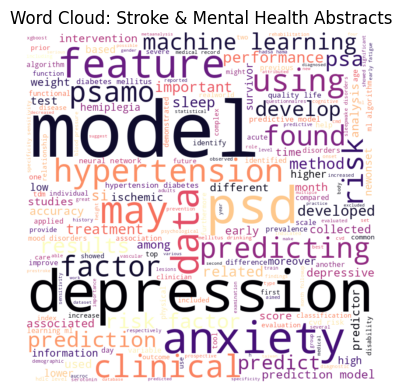

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Combine all tokens from 'tokens_no_stop_context' into one list
# You can remove .head(5000) to use the full dataset
all_tokens = sum(df['tokens_no_stop_context'].head(5000).tolist(), [])

# 2. Convert the list of tokens into a single string
text = ' '.join(all_tokens)

# 3. Create the WordCloud object
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    colormap='magma',  # Color palette
    min_font_size=10
).generate(text)

# 4. Display the WordCloud
plt.figure(figsize=(3.5, 3.5), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.title("Word Cloud: Stroke & Mental Health Abstracts", fontsize=12)
plt.show()


Lemmatization

Lemmatization is a process in natural language processing where words are reduced to their base or root form. Unlike stemming, which often simply chops off word endings, lemmatization considers the context and converts the word to its meaningful base form, which is known as a lemma. For example, the lemma of "am", "are", and "is" is "be", and the lemma of "mice" is "mouse".

This process is important in NLP as it helps in reducing the morphological complexity of words, bringing them down to their base or dictionary form. It aids in standardizing words with similar meanings so that they can be analyzed as a single item, improving the performance of various NLP tasks like text classification, sentiment analysis, and topic modeling.

Lemmatization in Python
To perform lemmatization in Python, the Natural Language Toolkit (NLTK) provides a WordNetLemmatizer class. At the beginning of the tutorial, we downloaded WordNet data via NLTK. WordNet is a large lexical database of English where nouns, verbs, adjectives, and adverbs are grouped into sets of cognitive synonyms (synsets), each expressing a distinct concept. In the following code:

We first instantiate WordNetLemmatizer.
We define a function get_wordnet_pos to map NLTK's part-of-speech tags to the format required by the lemmatizer. This step is important as lemmatization depends on a word's part-of-speech.
We define lemmatize_text which applies the lemmatizer to each token.
Finally, we apply this function to our DataFrame to get the lemmatized tokens.
This process results in tokens that are the base or dictionary form of the words, which is beneficial for consistent text analysis.

In [11]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download needed NLTK data (if not done yet)
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# 1. Function to map NLTK POS tags to WordNet tags
def get_wordnet_pos(word, pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

# 2. Instantiate the lemmatizer
lemmatizer = WordNetLemmatizer()

# 3. Function to lemmatize a list of tokens using POS tags
def lemmatize_tokens_with_pos(tokens):
    tagged_tokens = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word, tag)) for word, tag in tagged_tokens]

# 4. Apply lemmatization to the cleaned tokens
df['lemmatized'] = df['tokens_no_stop_context'].apply(lemmatize_tokens_with_pos)

# 5. Preview results
df[['tokens_no_stop_context', 'lemmatized']].head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,tokens_no_stop_context,lemmatized
0,"[anxiety, psa, caused, wide, public, concern, ...","[anxiety, psa, cause, wide, public, concern, r..."
1,"[introduction, depression, psd, serious, ische...","[introduction, depression, psd, serious, ische..."
2,"[currently, identification, increased, suicide...","[currently, identification, increase, suicide,..."
3,"[cardiovascular, disease, cvd, major, complica...","[cardiovascular, disease, cvd, major, complica..."
4,"[depression, common, complication, may, lead, ...","[depression, common, complication, may, lead, ..."


In [12]:
# Display key columns in your DataFrame
df[['abstract_expanded', 'tokens_no_stop_context', 'lemmatized']].head()


,abstract_expanded,tokens_no_stop_context,lemmatized
0,poststroke anxiety psa has caused wide public ...,"[anxiety, psa, caused, wide, public, concern, ...","[anxiety, psa, cause, wide, public, concern, r..."
1,introduction poststroke depression psd is a se...,"[introduction, depression, psd, serious, ische...","[introduction, depression, psd, serious, ische..."
2,currently the identification of stroke patient...,"[currently, identification, increased, suicide...","[currently, identification, increase, suicide,..."
3,cardiovascular disease cvd is a major complica...,"[cardiovascular, disease, cvd, major, complica...","[cardiovascular, disease, cvd, major, complica..."
4,depression is a common complication after a st...,"[depression, common, complication, may, lead, ...","[depression, common, complication, may, lead, ..."


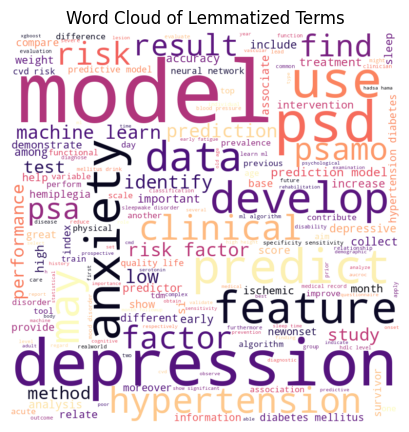

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Combine all tokens from the 'lemmatized' column into a single list
# You can remove .head(5000) to use the entire dataset
all_tokens = sum(df['lemmatized'].head(5000).tolist(), [])

# 2. Join the tokens into a single string for the WordCloud
text = ' '.join(all_tokens)

# 3. Create the WordCloud object
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    colormap='magma',
    min_font_size=10
).generate(text)

# 4. Plot the WordCloud image
plt.figure(figsize=(3.9, 3.9), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.title("Word Cloud of Lemmatized Terms", fontsize=12)
plt.show()


victoraizaton

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Join lemmatized tokens back into a string for each abstract
cleaned_texts = df['lemmatized'].apply(lambda x: ' '.join(x))

# 2. (Optional) Preview the first few processed abstracts
print("First 5 cleaned abstract texts (lemmatized):")
print(cleaned_texts.head())

# 3. Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# 4. Fit and transform the lemmatized text to produce the TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(cleaned_texts)

# 5. (Optional) Check matrix shape
print(f"\nTF-IDF Matrix Shape: {tfidf_matrix.shape}")  # (number of documents, number of unique terms)


First 5 cleaned abstract texts (lemmatized):
0    anxiety psa cause wide public concern recent y...
1    introduction depression psd serious ischemic e...
2    currently identification increase suicide risk...
3    cardiovascular disease cvd major complication ...
4    depression common complication may lead increa...
Name: lemmatized, dtype: object

TF-IDF Matrix Shape: (12, 891)


In [16]:
import gensim.downloader as api
import numpy as np

# 1. Load the pre-trained GloVe model (100-dimensional vectors)
glove_model = api.load('glove-wiki-gigaword-100')  # ~128MB

# 2. Define a function to convert lemmatized tokens into a GloVe-based document vector
def vectorize(tokens):
    # Filter out tokens not in the GloVe vocabulary
    tokens = [token for token in tokens if token in glove_model.key_to_index]

    # Return a zero vector if none of the tokens are in GloVe
    if len(tokens) == 0:
        return np.zeros(glove_model.vector_size)

    # Average the GloVe vectors for the tokens
    word_vectors = [glove_model[token] for token in tokens]
    return np.mean(word_vectors, axis=0)

# 3. Apply the function to your 'lemmatized' column
df['embedding'] = df['lemmatized'].apply(vectorize)

# 4. Preview the first few embeddings
df[['lemmatized', 'embedding']].head()


[==================================================] 100.0% 128.1/128.1MB downloaded


,lemmatized,embedding
0,"[anxiety, psa, cause, wide, public, concern, r...","[-0.11589383, 0.17748773, 0.040392432, 0.27499..."
1,"[introduction, depression, psd, serious, ische...","[-0.11232881, 0.16174172, 0.15707365, 0.195021..."
2,"[currently, identification, increase, suicide,...","[-0.18427475, 0.24716301, 0.030762447, 0.14706..."
3,"[cardiovascular, disease, cvd, major, complica...","[-0.07959322, 0.1201985, 0.01945245, 0.1892039..."
4,"[depression, common, complication, may, lead, ...","[-0.16118339, 0.20074454, -0.017093334, 0.3784..."


In [18]:
# Illustrative Example: Get the vector for a relevant word
word_vector = glove_model['depression']  # You can try 'anxiety', 'stroke', 'recovery', etc.
word_vector



array([ 0.10542  , -0.13691  ,  0.15946  ,  0.99195  , -1.1368   ,
        0.18614  ,  0.036245 , -0.6107   , -0.091113 , -0.52332  ,
        0.030946 , -0.35659  , -0.44533  , -0.12095  ,  1.7213   ,
       -0.27306  ,  0.502    , -0.45359  , -0.37612  , -0.36712  ,
        0.32663  ,  0.56371  , -0.58183  ,  0.39254  , -0.48831  ,
        0.4093   , -0.0067719, -1.1515   , -0.33624  ,  0.25515  ,
        0.48866  ,  0.47035  ,  0.046441 ,  0.042582 , -1.1799   ,
        0.19842  ,  0.57576  , -0.28609  , -0.090024 ,  0.61114  ,
       -0.8027   ,  0.097761 , -0.35865  , -0.29034  ,  0.76079  ,
        0.42944  ,  1.1057   ,  0.34321  ,  0.40805  , -0.47787  ,
       -0.63205  , -0.17783  ,  0.050688 ,  0.795    ,  0.84402  ,
       -1.5069   ,  0.51453  , -0.50486  ,  0.56217  ,  1.1522   ,
        0.24492  ,  1.8298   ,  0.33141  , -0.69176  ,  0.27301  ,
        0.629    , -0.015768 , -0.95589  ,  1.0203   , -0.54593  ,
       -0.28555  ,  0.099894 , -0.32071  ,  0.73616  , -0.0568

In [19]:
# 1. Convert the list of embeddings to string format for CSV export
df['embedding'] = df['embedding'].apply(lambda x: ','.join(map(str, x)))

# 2. Save the DataFrame to a CSV file
df.to_csv('preprocessed_abstracts.csv', index=False)
